In [1]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv


In [2]:
# Check uploaded files
import os

print(os.listdir())

['.config', 'twitter_training.csv', 'sample_data']


In [3]:
# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("twitter_training.csv", header=None)

# Assign column names
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

# Display first 5 rows
print("First 5 Rows of the Dataset:")
display(df.head())

First 5 Rows of the Dataset:


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
# Display dataset shape
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape:
(74682, 4)

Column Names:
Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


In [6]:
# Check duplicate rows
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
2700


In [7]:
# Display statistical summary
print("Statistical Summary:")
display(df.describe(include="all"))

Statistical Summary:


,Tweet_ID,Entity,Sentiment,Tweet
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


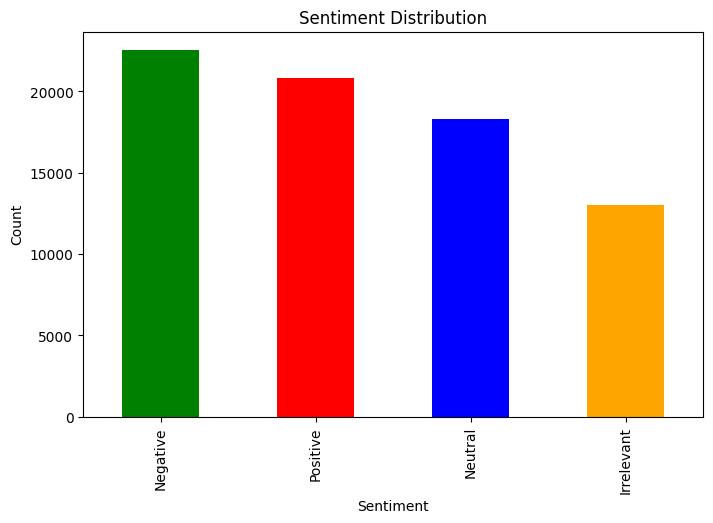

In [8]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df["Sentiment"].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
sentiment_counts.plot(kind="bar", color=["green", "red", "blue", "orange"])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

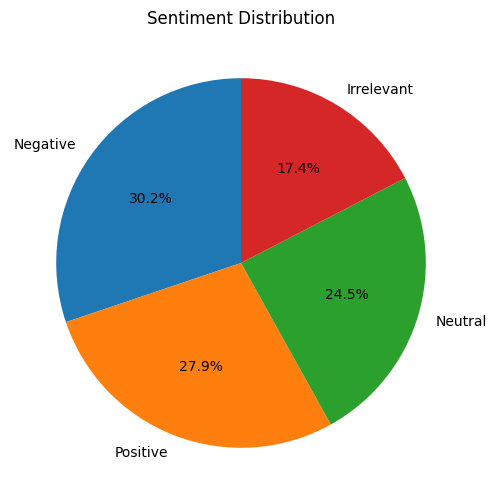

In [9]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")
plt.show()

In [10]:
# Remove rows where Tweet is missing
df = df.dropna(subset=["Tweet"])

# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset after cleaning
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (71656, 4)

Missing Values:
Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64


In [11]:
# Convert Sentiment into numbers
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Sentiment"] = encoder.fit_transform(df["Sentiment"])

print(df.head())

   Tweet_ID       Entity  Sentiment  \
0      2401  Borderlands          3   
1      2401  Borderlands          3   
2      2401  Borderlands          3   
3      2401  Borderlands          3   
4      2401  Borderlands          3   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X = tfidf.fit_transform(df["Tweet"])

# Target variable
y = df["Sentiment"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (71656, 5000)
Target Shape: (71656,)


In [13]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (57324, 5000)
Testing Data : (14332, 5000)


In [17]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6426876918783143

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.36      0.49      2529
           1       0.64      0.81      0.71      4383
           2       0.67      0.54      0.60      3543
           3       0.61      0.73      0.66      3877

    accuracy                           0.64     14332
   macro avg       0.66      0.61      0.62     14332
weighted avg       0.65      0.64      0.63     14332



In [19]:
sample_text = ["This product is amazing and I love it"]

sample_vector = tfidf.transform(sample_text)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", encoder.inverse_transform(prediction)[0])

Predicted Sentiment: Positive


In [20]:
# Sample prediction
sample_text = ["This product is amazing and I love it"]

# Convert text into TF-IDF features
sample_vector = tfidf.transform(sample_text)

# Predict sentiment
prediction = model.predict(sample_vector)

# Convert number back to sentiment label
predicted_sentiment = encoder.inverse_transform(prediction)

print("Predicted Sentiment:", predicted_sentiment[0])

Predicted Sentiment: Positive


In [21]:
print("Customer Feedback Sentiment Analysis Project Completed Successfully!")

Customer Feedback Sentiment Analysis Project Completed Successfully!
